<a href="https://colab.research.google.com/github/KellyTBG/Podostemaceae-niche-modelling/blob/main/03_soil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Environmental Variable Acquisition: Soil**

## *Developed by Kelly T. Bocanegra-González at the Bedoya Group (NYBG), May 2026.*

This notebook corresponds to the soil data acquisition and exploratory analysis stage of environmental predictors for Podostemaceae niche modelling. Soil variables were obtained from the ISRIC SoilGrids global soil database (https://soilgrids.org/), which provides high-resolution spatial predictions of soil properties derived from machine learning models and globally standardized environmental covariates.

This notebook focuses exclusively on:

- Downloading and organizing SoilGrids raster layers for the Neotropical region.
- Visualizing soil variables for quality control and exploratory assessment.
- Extracting soil values at species occurrence points.
- Exploring soil property distributions across Podostemaceae occurrences.
- Evaluating correlations and redundancy among soil predictors.
- Preparing soil variables for integration into the environmental matrix used in ecological niche modelling analyses.

All variables were downloaded for the 0–5 cm depth interval using mean predicted values.

Subsequent analyses will integrate soil, climatic, topographic, and hydrological predictors into combined environmental datasets for multivariate analyses, PCA exploration, variable selection, and ecological niche modelling.

### `bdod`
Bulk density of dry soil.

Represents soil compaction and density. High values are generally associated with compacted or mineral-dominated substrates, whereas lower values indicate more porous soils with higher organic content.

### `cec`
Cation exchange capacity.

Represents the capacity of soils to retain and exchange positively charged nutrients. Higher values generally indicate greater nutrient retention potential.

### `cfvo`
Coarse fragment volume.

Represents the proportion of coarse fragments and rocky material within the soil. This variable may be particularly relevant for Podostemaceae because many species are associated with rocky riverbeds and exposed bedrock.

### `clay`
Clay content.

Represents the proportion of fine clay particles within the soil. Clay-rich substrates generally retain more water and nutrients.

### `nitrogen`
Total nitrogen content.

Represents soil nitrogen availability and overall fertility conditions.

### `phh2o`
Soil pH measured in water.

Represents soil acidity or alkalinity and may influence nutrient availability and substrate chemistry.

### `sand`
Sand content.

Represents the proportion of coarse mineral particles within the soil. Sandy substrates are generally associated with higher drainage and lower water retention.

### `silt`
Silt content.

Represents intermediate-sized soil particles between sand and clay. Silt may influence sediment deposition and substrate stability.

### `soc`
Soil organic carbon.

Represents the amount of organic carbon stored in the soil and is often associated with organic matter accumulation.

### `ocd`
Organic carbon density.

Represents the density of organic carbon within the soil profile and may reflect long-term organic matter accumulation.

In [ ]:
# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


I extracted SoilGrids values directly at the occurrence points because downloading full soil raster layers for the entire study area would be heavy, slow, and unnecessary for this exploratory matrix. Since the current analysis only needs soil information associated with each occurrence record, point-based extraction is a more efficient way to add soil predictors to the environmental dataset.

In [ ]:
# Extract SoilGrids values directly at occurrence points

import requests
import pandas as pd
from tqdm import tqdm

# Load occurrence/environmental matrix

soil_df = pd.read_csv(
    "/content/drive/MyDrive/Podostemaceae/"
    "Niche/04_results/"
    "Podostemaceae_environmental_matrix_bio_topo_selected.csv"
)

print(soil_df.shape)

soil_df.head()

(3500, 34)


,Species,Country,Department_Province,Locality,Latitude,Longitude,Elevation,River,Subbasin,Basin,...,bio_14,bio_4,bio_5,SLOPE,topo_CURV,topo_PLFMCURV,topo_PROFCURV,topo_hs (1),hydro_MD_area_log10,hydro_dinf_area_log10
0,NaN,Brazil,Pará,"Nova Mocajuba, rio Caeté, aprox. 3,1 km ao oés...",-1.288750,-46.910367,NaN,NaN,NaN,NaN,...,13.0,47.934601,32.299999,0.029648,0.000004,-2.290816e-07,-0.000010,180.661530,5.403859,6.525160
1,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,2.730772,-53.924988,NaN,NaN,NaN,NaN,...,52.0,50.915836,32.299999,0.042573,-0.000173,1.972856e-07,-0.000082,182.025757,4.824249,6.521545
2,Mourera aspera,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.928194,-51.832722,311.0,NaN,NaN,NaN,...,66.0,300.796906,29.799999,0.028862,0.000116,-5.076539e-07,0.000220,180.251007,5.052110,8.590564
3,Apinagia richardiana,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.931139,-51.838444,310.0,NaN,NaN,NaN,...,67.0,298.733124,29.700001,0.083837,-0.000026,-5.662302e-06,0.000157,170.399124,5.102567,8.390217
4,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,3.913025,-54.261642,NaN,NaN,NaN,NaN,...,78.0,53.983353,32.299999,0.031316,0.000021,-2.926894e-06,0.000211,180.053406,4.452710,8.574284


In [ ]:
# Extract SoilGrids values directly at occurrence points

import requests
import pandas as pd
from tqdm import tqdm

# Load occurrence/environmental matrix

soil_df = pd.read_csv(
    "/content/drive/MyDrive/Podostemaceae/"
    "Niche/04_results/"
    "Podostemaceae_environmental_matrix_bio_topo_selected.csv"
)

print(soil_df.shape)

soil_df.head()

(3500, 34)


,Species,Country,Department_Province,Locality,Latitude,Longitude,Elevation,River,Subbasin,Basin,...,bio_14,bio_4,bio_5,SLOPE,topo_CURV,topo_PLFMCURV,topo_PROFCURV,topo_hs (1),hydro_MD_area_log10,hydro_dinf_area_log10
0,NaN,Brazil,Pará,"Nova Mocajuba, rio Caeté, aprox. 3,1 km ao oés...",-1.288750,-46.910367,NaN,NaN,NaN,NaN,...,13.0,47.934601,32.299999,0.029648,0.000004,-2.290816e-07,-0.000010,180.661530,5.403859,6.525160
1,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,2.730772,-53.924988,NaN,NaN,NaN,NaN,...,52.0,50.915836,32.299999,0.042573,-0.000173,1.972856e-07,-0.000082,182.025757,4.824249,6.521545
2,Mourera aspera,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.928194,-51.832722,311.0,NaN,NaN,NaN,...,66.0,300.796906,29.799999,0.028862,0.000116,-5.076539e-07,0.000220,180.251007,5.052110,8.590564
3,Apinagia richardiana,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.931139,-51.838444,310.0,NaN,NaN,NaN,...,67.0,298.733124,29.700001,0.083837,-0.000026,-5.662302e-06,0.000157,170.399124,5.102567,8.390217
4,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,3.913025,-54.261642,NaN,NaN,NaN,NaN,...,78.0,53.983353,32.299999,0.031316,0.000021,-2.926894e-06,0.000211,180.053406,4.452710,8.574284


In [ ]:
# Query SoilGrids API for each occurrence point

for idx, row in tqdm(
    soil_df.iterrows(),
    total=len(soil_df)
):

    lat = row["Latitude"]
    lon = row["Longitude"]

    url = (
        "https://rest.isric.org/soilgrids/v2.0/properties/query"
        f"?lon={lon}&lat={lat}"
       "&property=bdod"
        "&property=cec"
        "&property=cfvo"
        "&property=clay"
        "&property=nitrogen"
        "&property=phh2o"
        "&property=sand"
        "&property=silt"
        "&property=soc"
        "&property=ocd"
        "&depth=0-5cm"
        "&value=mean"
    )

    try:
        r = requests.get(url)
        data = r.json()

        layers = data["properties"]["layers"]

        for layer in layers:
            var = layer["name"]

            value = (
                layer["depths"][0]
                ["values"]["mean"]
            )

            soil_df.at[idx, var] = value

    except:
        continue

print("Soil extraction completed.")

100%|██████████| 3500/3500 [3:11:52<00:00,  3.29s/it]

Soil extraction completed.


In [ ]:
# Missing values in soil variables

soil_vars = [
    "bdod",
    "cec",
    "cfvo",
    "clay",
    "nitrogen",
    "phh2o",
    "sand",
    "silt",
    "soc",
    "ocd"
]

soil_df[soil_vars].isna().sum()

,0
bdod,496
cec,470
cfvo,469
clay,469
nitrogen,469
phh2o,470
sand,469
silt,469
soc,470
ocd,470


In [ ]:
# Descriptive statistics

soil_df[soil_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
bdod,3004.0,114.840546,12.061705,66.0,108.0,115.0,124.00,147.0
cec,3030.0,178.738284,50.080699,66.0,139.0,174.0,215.00,398.0
cfvo,3031.0,92.753877,46.491159,3.0,62.0,85.0,112.00,323.0
clay,3031.0,324.149456,84.314117,114.0,266.0,320.0,368.00,606.0
nitrogen,3031.0,340.776641,135.979175,96.0,239.5,315.0,424.00,828.0
phh2o,3030.0,53.047525,5.799135,39.0,50.0,53.0,56.00,78.0
sand,3031.0,396.322006,120.624204,10.0,319.0,388.0,479.00,761.0
silt,3031.0,279.528538,63.270918,96.0,235.0,286.0,325.00,608.0
soc,3030.0,429.186799,181.951222,86.0,297.0,393.0,526.00,1484.0
ocd,3030.0,372.251815,83.483625,174.0,310.0,358.0,427.75,662.0


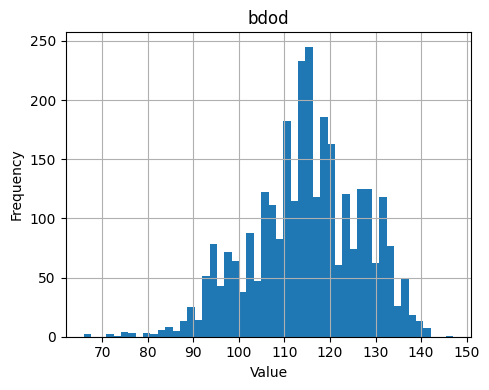

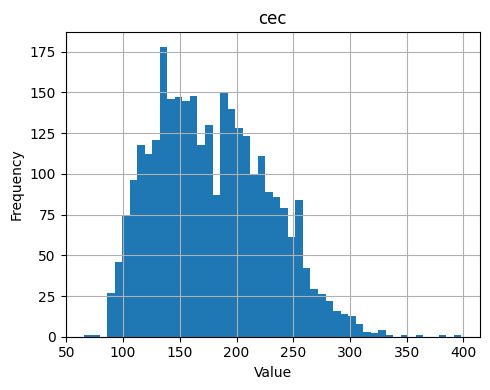

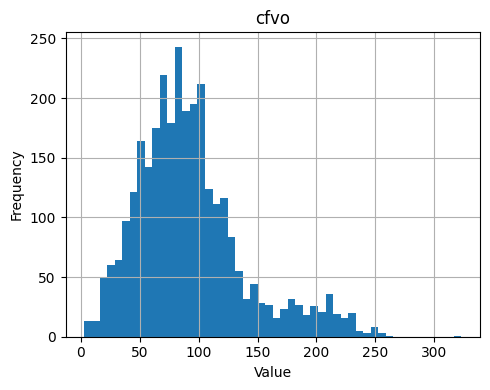

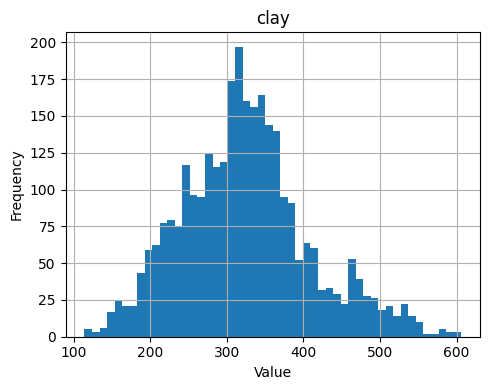

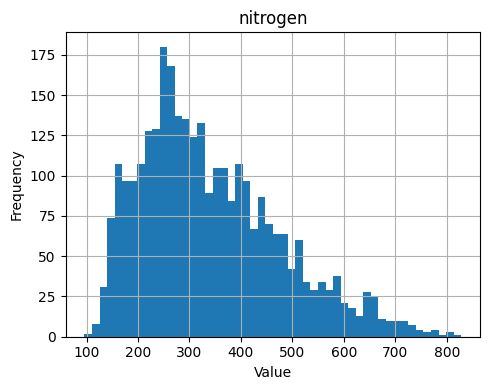

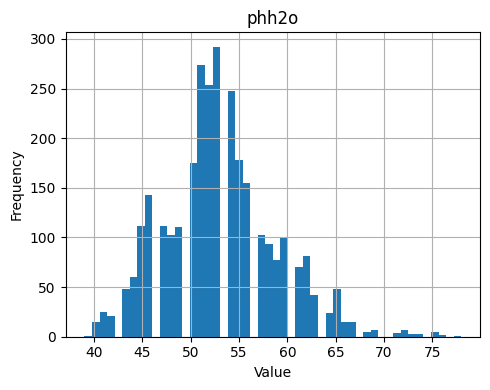

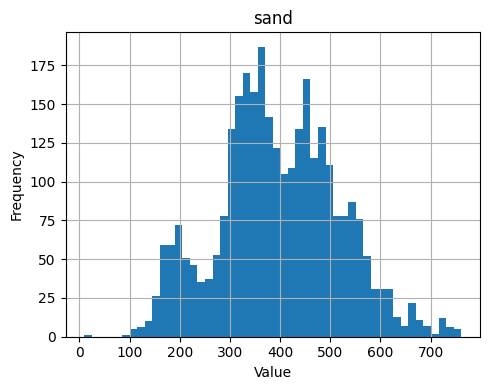

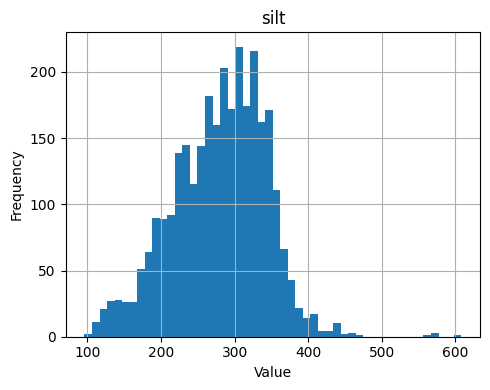

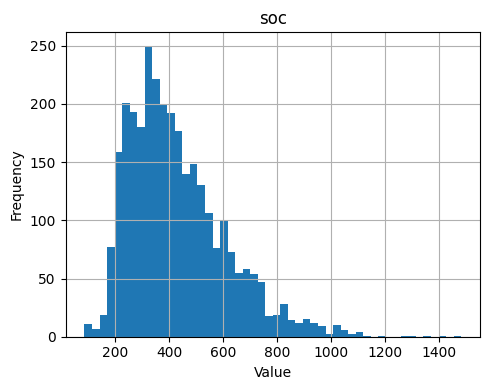

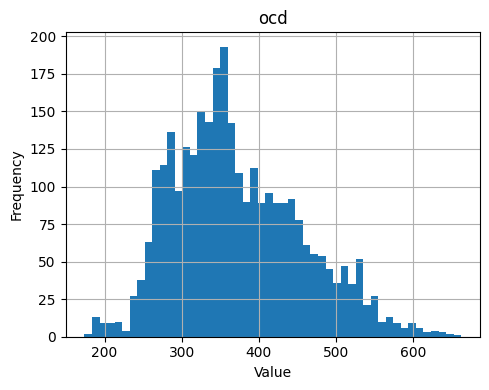

In [ ]:
# Histograms of soil variables

import matplotlib.pyplot as plt

for var in soil_vars:

    plt.figure(figsize=(5,4))

    soil_df[var].hist(bins=50)

    plt.title(var)

    plt.xlabel("Value")
    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.show()

In [ ]:
# Log10 transformation of skewed soil variables
# NEED TO CHANGE THE VLAUES OF THE RASTER AS WELL

import numpy as np

soil_df["soc_log10"] = np.log10(
    soil_df["soc"] + 1
)

soil_df["cfvo_log10"] = np.log10(
    soil_df["cfvo"] + 1
)

soil_df["nitrogen_log10"] = np.log10(
    soil_df["nitrogen"] + 1
)

print("Log10 transformations completed.")

Log10 transformations completed.


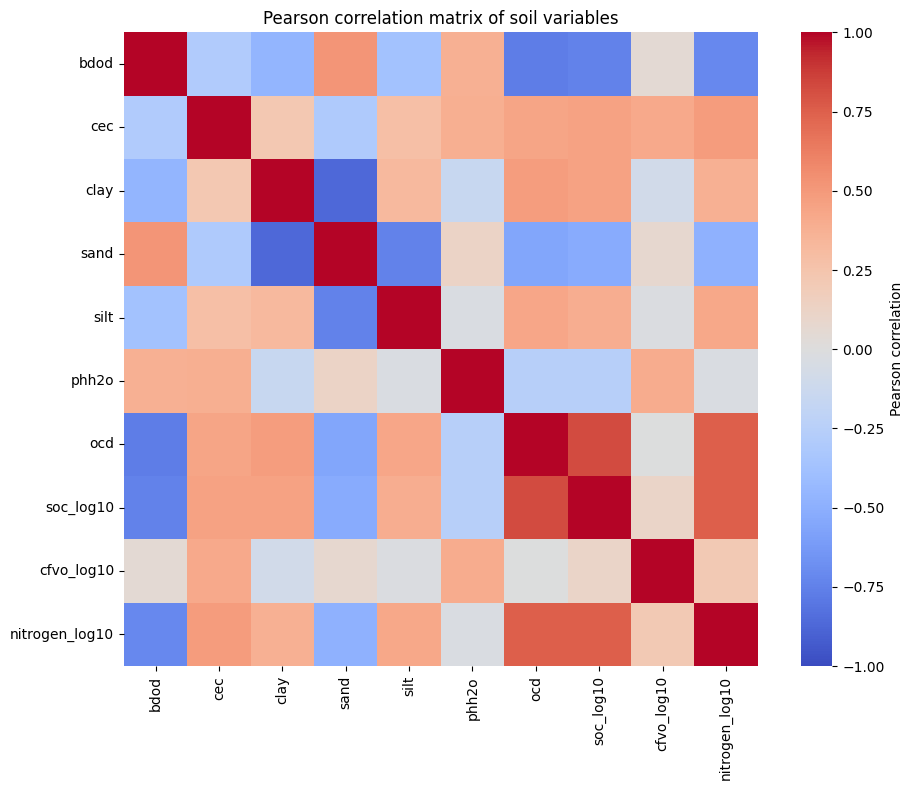

Figure saved:
/content/drive/MyDrive/Podostemaceae/Niche/05_figures/soil_correlation_matrix.png


In [ ]:
# Pearson correlation matrix for soil variables

import seaborn as sns
import matplotlib.pyplot as plt

soil_corr_vars = [

   "bdod",
    "cec",
    "clay",
    "sand",
    "silt",
    "phh2o",
    "ocd",

    "soc_log10",
    "cfvo_log10",
    "nitrogen_log10"
]

#correlation matrix
corr_matrix = (
    soil_df[soil_corr_vars]
    .corr(method="pearson")
)

# plot
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0,
    cbar_kws={"label": "Pearson correlation"}
)

# Remove external black border
for spine in ax.spines.values():
    spine.set_visible(False)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title(
    "Pearson correlation matrix of soil variables"
)

plt.tight_layout()

# save figure
output_fig = (
    "/content/drive/MyDrive/Podostemaceae/"
    "Niche/05_figures/"
    "soil_correlation_matrix.png"
)

plt.savefig(
    output_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(output_fig)

In [ ]:
# Table of highly correlated soil variable pairs

import numpy as np
import pandas as pd

# absolute correlation matrix
corr_abs = corr_matrix.abs()

# upper triangle
upper = corr_abs.where(
    np.triu(
        np.ones(corr_abs.shape),
        k=1
    ).astype(bool)
)

# threshold
threshold = 0.80

# extract highly correlated pairs
high_corr_pairs = []

for col in upper.columns:

    for row in upper.index:

        value = upper.loc[row, col]

        if pd.notnull(value) and value >= threshold:

            high_corr_pairs.append([
                row,
                col,
                value
            ])

# dataframe
soil_corr_pairs = pd.DataFrame(
    high_corr_pairs,
    columns=[
        "Variable_1",
        "Variable_2",
        "Pearson_r"
    ]
)

# sort
soil_corr_pairs = soil_corr_pairs.sort_values(
    by="Pearson_r",
    ascending=False
)

# display
display(soil_corr_pairs)

# save table
output_table = (
    "/content/drive/MyDrive/Podostemaceae/"
    "Niche/04_results/"
    "highly_correlated_SOIL_pairs.csv"
)

soil_corr_pairs.to_csv(
    output_table,
    index=False
)

print("Saved:")
print(output_table)

,Variable_1,Variable_2,Pearson_r
0,clay,sand,0.868076
1,ocd,soc_log10,0.826352


Saved:
/content/drive/MyDrive/Podostemaceae/Niche/04_results/highly_correlated_SOIL_pairs.csv


In [ ]:
# Selected soil variables

selected_soil_vars = [

    "bdod",
    "cec",
    "cfvo_log10",
    "clay",
    "nitrogen_log10",
    "phh2o",
    "silt",
    "soc_log10"
]

# Save final soil-selected environmental matrix

soil_selected_df = soil_df.copy()

output_csv = (
    "/content/drive/MyDrive/Podostemaceae/"
    "Niche/04_results/"
    "Podostemaceae_environmental_matrix_bio_topo_soil_selected.csv"
)

soil_selected_df.to_csv(
    output_csv,
    index=False
)

print("Saved:")
print(output_csv)

Saved:
/content/drive/MyDrive/Podostemaceae/Niche/04_results/Podostemaceae_environmental_matrix_bio_topo_soil_selected.csv


**Here start PCA and charts**